## Train Masking ResNeXt model

Trains the **Masking ResNeXt** model from:
> Satterlee et al. (2025) *Robust image-based cross-sectional grain boundary detection and characterization using machine learning*, Journal of Intelligent Manufacturing 36:3067-3095

The architecture is a pretrained **ResNeXt50_32x4d** encoder with a **UNet-style decoder head**.
It uses the same 256×256 patch format and 0/1/2 mask encoding as the UNet model, so training data prepared with `seg.patchify_training_data` works directly.

Output probabilities match the UNet convention (channel 0 = background, 1 = grain interior, 2 = boundary), so the saved model can be dropped into the segmentation pipeline in place of the UNet.

In [16]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.functional as TF
import random

import segmenteverygrain as seg
from segmenteverygrain.resnext_model import MaskingResNeXt, weighted_crossentropy_torch

device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: mps


In [17]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Folder containing paired *image* and *mask* files for training.
# Files from seg.save_training_masks (in prediction_outputs/) work directly here.
input_dir = './segmenteverygrain_training_data/smaller_resnet_test/'

# Patches will be written to patch_dir/Patches/images/ and patch_dir/Patches/labels/
patch_dir = './segmenteverygrain_training_data/'

# Where to save the trained model
save_path = './models/resnext_model.pth'

# ── Hyperparameters ───────────────────────────────────────────────────────────
val_split     = 0.15
batch_size    = 8
epochs        = 50
lr            = 1e-4
patience      = 10
class_weights = (0.6, 1.0, 5.0)  # background / interior / boundary


In [18]:
# Generate 256x256 patches from the full-size images and masks.
# This uses the same utility as the UNet training pipeline.
# Skip this cell if patches already exist in patch_dir/Patches/.
image_dir, mask_dir = seg.patchify_training_data(input_dir, patch_dir)
print(f'Image patches: {image_dir}')
print(f'Mask patches:  {mask_dir}')
print(f'Patches found: {len(glob.glob(os.path.join(image_dir, "*.png")))}')


100%|██████████| 13/13 [00:02<00:00,  4.38it/s]

Image patches: ./segmenteverygrain_training_data/Patches/images
Mask patches:  ./segmenteverygrain_training_data/Patches/labels
Patches found: 3140


In [19]:
class GrainPatchDataset(Dataset):
    """Loads paired 256x256 image/mask PNG patches produced by patchify_training_data.

    save_training_masks writes both _sam_mask and _unet_mask for each image,
    so after patchifying there are twice as many label patches as image patches.
    mask_suffix selects which set to use: 'sam' (default) or 'unet'.
    SAM masks tend to have cleaner grain outlines; UNet masks are faster to generate.
    """

    def __init__(self, image_dir, mask_dir, augment=True, mask_suffix='sam'):
        self.image_paths = sorted(glob.glob(os.path.join(image_dir, "*.png")))
        all_masks        = sorted(glob.glob(os.path.join(mask_dir,  "*.png")))

        # patchify_training_data names all patches im000.png, im001.png, etc.,
        # so we cannot filter by filename. Instead we rely on the fact that
        # patchify processes mask files in alphabetical order: _sam_mask comes
        # before _unet_mask, so the first half of label patches are SAM and
        # the second half are UNet.
        n_total = len(all_masks)
        n_imgs  = len(self.image_paths)
        assert n_total % n_imgs == 0, (
            f"Expected label patches to be a multiple of image patches, "
            f"got {n_total} masks for {n_imgs} images.")
        factor = n_total // n_imgs  # should be 2
        mask_index = {"sam": 0, "unet": 1 if factor > 1 else 0}
        offset = mask_index.get(mask_suffix, 0)
        # slice: every factor-th patch starting at offset
        self.mask_paths = all_masks[offset * n_imgs : (offset + 1) * n_imgs]

        assert len(self.image_paths) == len(self.mask_paths), (
            f"Mismatch: {len(self.image_paths)} images vs {len(self.mask_paths)} masks")
        self.augment = augment
        print(f'Using {mask_suffix} masks ({len(self.image_paths)} patch pairs)')

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img  = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")

        if self.augment:
            if random.random() > 0.5:
                img  = TF.hflip(img)
                mask = TF.hflip(mask)
            if random.random() > 0.5:
                img  = TF.vflip(img)
                mask = TF.vflip(mask)
            k = random.randint(0, 3)
            if k:
                img  = TF.rotate(img,  90 * k)
                mask = TF.rotate(mask, 90 * k)

        img_t  = torch.from_numpy(np.array(img).astype("float32") / 255.0).permute(2, 0, 1)
        mask_t = torch.from_numpy(np.array(mask).astype("int64"))
        return img_t, mask_t


# Change mask_suffix to 'unet' to train on UNet predictions instead
full_dataset = GrainPatchDataset(image_dir, mask_dir, augment=True, mask_suffix='sam')
n_val   = max(1, int(len(full_dataset) * val_split))
n_train = len(full_dataset) - n_val
train_dataset, val_dataset = random_split(full_dataset, [n_train, n_val])

val_dataset.dataset.augment = False

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0)

print(f'Training patches:   {n_train}')
print(f'Validation patches: {n_val}')


Using sam masks (3140 patch pairs)
Training patches:   2669
Validation patches: 471


In [20]:
model = MaskingResNeXt(num_classes=3, pretrained=True).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=patience//2, factor=0.5)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable:,}')


Total parameters:     94,251,683
Trainable parameters: 94,251,683


In [21]:
train_losses, val_losses = [], []
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(epochs):
    # ── training ──────────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    for imgs, masks in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [train]', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = weighted_crossentropy_torch(preds, masks, class_weights, device)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / n_train

    # ── validation ────────────────────────────────────────────────────────────
    model.eval()
    running_val = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            loss  = weighted_crossentropy_torch(preds, masks, class_weights, device)
            running_val += loss.item() * imgs.size(0)
    val_loss = running_val / n_val

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f'Epoch {epoch+1:3d}/{epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}')

    # ── early stopping + checkpoint ───────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        os.makedirs(os.path.dirname(save_path) or '.', exist_ok=True)
        torch.save(model.state_dict(), save_path)
        print(f'  ✓ Saved best model (val_loss={best_val_loss:.4f})')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f'Early stopping after {epoch+1} epochs (no improvement for {patience} epochs).')
            break

print(f'\nBest validation loss: {best_val_loss:.4f}')
print(f'Model saved to: {save_path}')

Epoch   1/50  train_loss=0.8609  val_loss=0.7583
  ✓ Saved best model (val_loss=0.7583)


Epoch   2/50  train_loss=0.7334  val_loss=0.6944
  ✓ Saved best model (val_loss=0.6944)


Epoch   3/50  train_loss=0.6791  val_loss=0.6588
  ✓ Saved best model (val_loss=0.6588)


Epoch   4/50  train_loss=0.6501  val_loss=0.6412
  ✓ Saved best model (val_loss=0.6412)


Epoch   5/50  train_loss=0.6314  val_loss=0.6291
  ✓ Saved best model (val_loss=0.6291)


...

Epoch  46/50  train_loss=0.5604  val_loss=0.5712
  ✓ Saved best model (val_loss=0.5712)


Epoch  47/50  train_loss=0.5602  val_loss=0.5703
  ✓ Saved best model (val_loss=0.5703)


Epoch  48/50  train_loss=0.5599  val_loss=0.5713


Epoch  49/50  train_loss=0.5598  val_loss=0.5714


Epoch  50/50  train_loss=0.5596  val_loss=0.5705

Best validation loss: 0.5703
Model saved to: ./models/resnext_model.pth


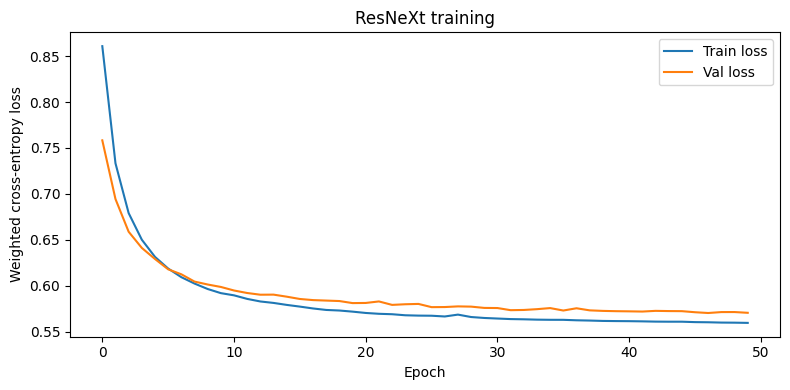

In [22]:
# Plot training curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train loss')
ax.plot(val_losses,   label='Val loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Weighted cross-entropy loss')
ax.set_title('ResNeXt training')
ax.legend()
plt.tight_layout()
plt.show()

## Quick sanity-check on a single patch

Loads the best saved model and runs inference on the first validation patch to confirm the output looks reasonable.

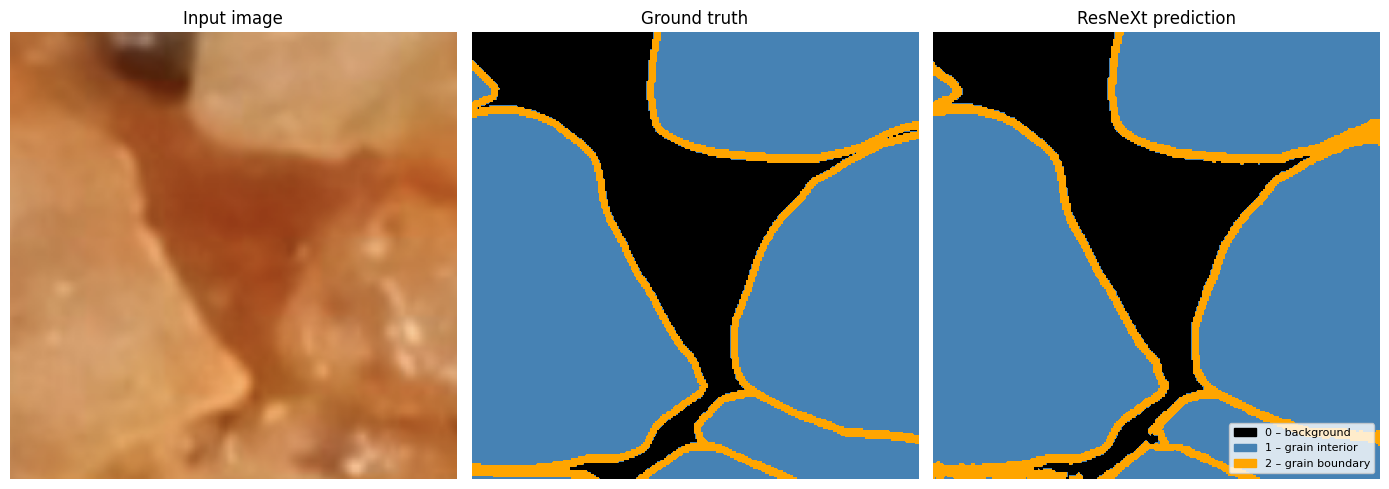

In [23]:
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from segmenteverygrain.resnext_model import load_resnext, predict_patch_torch

model_check = load_resnext(save_path, device=device)
model_check = model_check.to(device)

# Grab one validation image+mask
img_np  = np.array(Image.open(val_dataset.dataset.image_paths[val_dataset.indices[0]]).convert('RGB'))
mask_np = np.array(Image.open(val_dataset.dataset.mask_paths [val_dataset.indices[0]]).convert('L'))

pred_prob = predict_patch_torch(model_check, img_np, device=device)  # H×W×3
pred_mask = np.argmax(pred_prob, axis=2).astype(np.uint8)             # H×W  (0/1/2)

cmap    = ListedColormap(['black', 'steelblue', 'orange'])
patches = [
    mpatches.Patch(color='black',     label='0 – background'),
    mpatches.Patch(color='steelblue', label='1 – grain interior'),
    mpatches.Patch(color='orange',    label='2 – grain boundary'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img_np);                                             axes[0].set_title('Input image')
axes[1].imshow(mask_np,  cmap=cmap, vmin=0, vmax=2);               axes[1].set_title('Ground truth')
axes[2].imshow(pred_mask, cmap=cmap, vmin=0, vmax=2);              axes[2].set_title('ResNeXt prediction')
for ax in axes:
    ax.axis('off')
axes[2].legend(handles=patches, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

## Use the trained ResNeXt in the main segmentation pipeline

The ResNeXt produces the same `image_pred` shape (H×W×3) as the Keras UNet, so you can use it as a drop-in replacement:

```python
from segmenteverygrain.resnext_model import load_resnext, predict_patch_torch

resnext = load_resnext('./models/resnext_model.pth', device='mps')

# Replace seg.predict_image(image, unet, I=256) with:
image_pred = predict_patch_torch(resnext, image, device='mps')

# Then continue with label_grains, sam_segmentation, etc. as normal.
```